# Data Analysis

In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [13]:
data = pd.read_csv('data/cleaned_aqi.csv')
print(data.head())

         date   pm25
0  2026-03-01  145.0
1  2026-03-02  144.0
2  2026-03-03  154.0
3  2026-03-04  154.0
4  2026-03-05  147.0


In [14]:
data['year'] = pd.to_datetime(data['date']).dt.year
print(data['year'].value_counts(ascending=True))

year
2026     68
2025    189
2017    248
2023    324
2024    338
2018    342
2021    343
2019    346
2022    356
2020    357
Name: count, dtype: int64


year
2017     96.750000
2018    112.169591
2019    106.895954
2020     87.039216
2021     98.798834
2022     95.415730
2023     98.969136
2024    108.905325
2025     93.153439
2026    141.485294
Name: pm25, dtype: float64


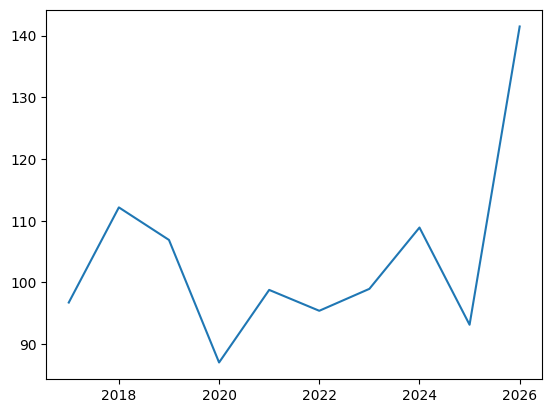

In [18]:
yearly_avg = data.groupby('year')['pm25'].mean()
print(yearly_avg)
plt.plot(yearly_avg.index, yearly_avg.values)

<Axes: xlabel='date'>

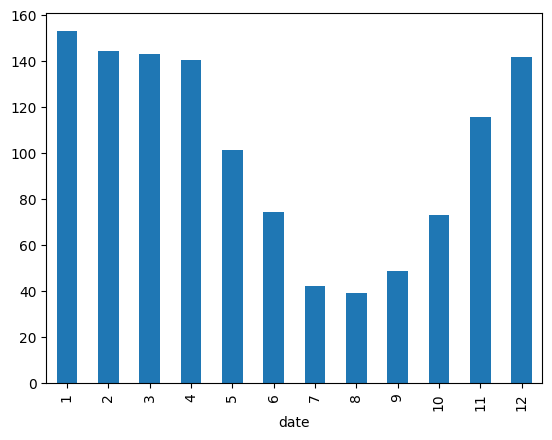

In [20]:
data['date'] = pd.to_datetime(data['date'])
monthly_avg = data.groupby(data['date'].dt.month)['pm25'].mean()
monthly_avg.plot(kind='bar')

<Axes: xlabel='date'>

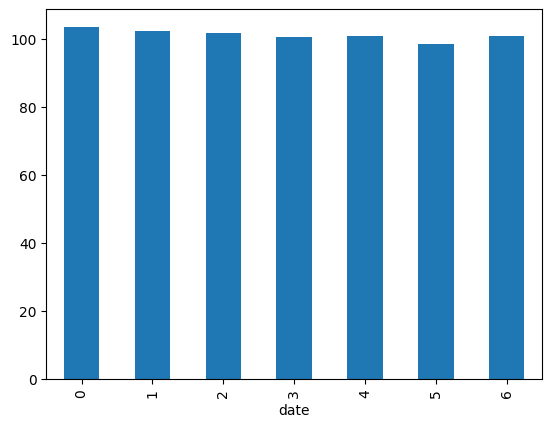

In [21]:
data['date'] = pd.to_datetime(data['date'])
weekly_avg = data.groupby(data['date'].dt.day_of_week)['pm25'].mean()
weekly_avg.plot(kind='bar')

In [24]:
threshold = data['pm25'].quantile(0.95)
spikes = data[data['pm25'] > threshold]
print(spikes)

           date   pm25  year
200  2025-01-05  177.0  2025
335  2024-12-28  178.0  2024
425  2024-04-03  180.0  2024
429  2024-04-07  182.0  2024
430  2024-04-08  184.0  2024
...         ...    ...   ...
2826 2017-04-11  179.0  2017
2827 2017-04-12  194.0  2017
2828 2017-04-13  213.0  2017
2829 2017-04-14  192.0  2017
2847 2017-05-07  176.0  2017

[143 rows x 3 columns]


<Axes: xlabel='category'>

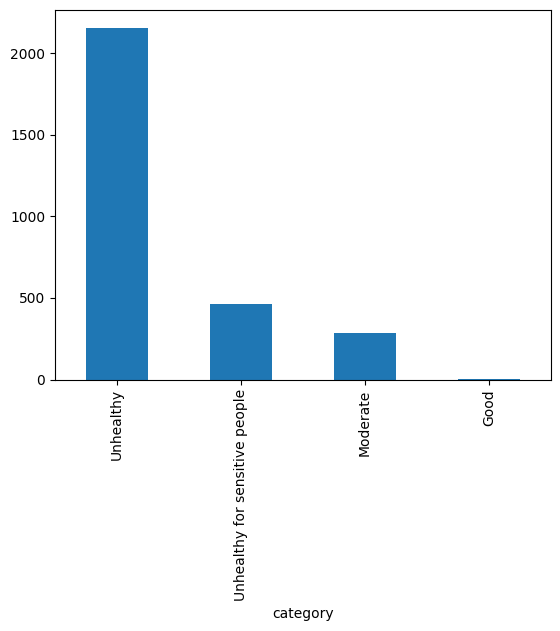

In [26]:
def pm_category(pm):
    if pm <= 12:
        return 'Good'
    elif pm <= 35.4:
        return 'Moderate'
    elif pm <= 55.4:
        return 'Unhealthy for sensitive people'
    else: 
        return 'Unhealthy'
    
data['category'] = data['pm25'].apply(pm_category)
data['category'].value_counts().plot(kind='bar')